In [1]:
! pip install xgboost
! pip install lightgbm
! pip install catboost

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
!pip install xgboost
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV


The file GDSC_DATASET.csv is a pre‑merged dataset that already integrates drug response data, genomic features, and drug annotations from the original GDSC files. Therefore, we load this consolidated dataset directly without performing additional merging.


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
gdsc=pd.read_csv("GDSC_DATASET.csv")


# Dataset Overview

In [4]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


* DATASET: Identifier for the specific GDSC dataset version.
* NLME_RESULT_ID: Unique identifier for the non-linear mixed effects model result.
* NLME_CURVE_ID: Identifier for the dose-response curve fitted by NLME.
* COSMIC_ID: Unique identifier for the cell line from the COSMIC database.
* CELL_LINE_NAME: Name of the cancer cell line used in the experiment.
* SANGER_MODEL_ID: Identifier used by the Sanger Institute for the cell line model.
* TCGA_DESC: Description of the cancer type according to The Cancer Genome Atlas.
* DRUG_ID: Unique identifier for the drug used in the experiment.
* DRUG_NAME: Name of the drug used in the experiment.
* PUTATIVE_TARGET: The presumed molecular target of the drug.
* PATHWAY_NAME: The biological pathway affected by the drug.
* COMPANY_ID: Identifier for the company that provided the drug.
* GDSC Tissue descriptor 1: Primary tissue type classification.
* GDSC Tissue descriptor 2: Secondary tissue type classification.
* WEBRELEASE: Date or version of web release for this data.
* MIN_CONC: Minimum concentration of the drug used in the experiment.
* MAX_CONC: Maximum concentration of the drug used in the experiment.
* LN_IC50: Natural log of the half-maximal inhibitory concentration (IC50).
* AUC: Area Under the Curve, a measure of drug effectiveness.
* RMSE: Root Mean Square Error, indicating the fit quality of the dose-response curve.
* Z_SCORE: Standardized score of the drug response, allowing comparison across different drugs and cell lines.
* TARGET: The molecular target(s) of the drug.
* TARGET_PATHWAY: The biological pathway(s) targeted by the drug.

In [5]:
gdsc.columns.tolist()

['COSMIC_ID',
 'CELL_LINE_NAME',
 'TCGA_DESC',
 'DRUG_ID',
 'DRUG_NAME',
 'LN_IC50',
 'AUC',
 'Z_SCORE',
 'GDSC Tissue descriptor 1',
 'GDSC Tissue descriptor 2',
 'Cancer Type (matching TCGA label)',
 'Microsatellite instability Status (MSI)',
 'Screen Medium',
 'Growth Properties',
 'CNA',
 'Gene Expression',
 'Methylation',
 'TARGET',
 'TARGET_PATHWAY']

In [6]:
gdsc.shape

(242035, 19)

In [7]:
gdsc.isna().sum()

COSMIC_ID                                      0
CELL_LINE_NAME                                 0
TCGA_DESC                                   1067
DRUG_ID                                        0
DRUG_NAME                                      0
LN_IC50                                        0
AUC                                            0
Z_SCORE                                        0
GDSC Tissue descriptor 1                    9366
GDSC Tissue descriptor 2                    9366
Cancer Type (matching TCGA label)          51446
Microsatellite instability Status (MSI)    12353
Screen Medium                               9366
Growth Properties                           9366
CNA                                         9366
Gene Expression                             9366
Methylation                                 9366
TARGET                                     27155
TARGET_PATHWAY                                 0
dtype: int64

* percentage of missing values

In [8]:
(gdsc.isna().sum() / len(gdsc) * 100).sort_values(ascending=False)

Cancer Type (matching TCGA label)          21.255604
TARGET                                     11.219452
Microsatellite instability Status (MSI)     5.103807
GDSC Tissue descriptor 2                    3.869688
Methylation                                 3.869688
Gene Expression                             3.869688
CNA                                         3.869688
Growth Properties                           3.869688
GDSC Tissue descriptor 1                    3.869688
Screen Medium                               3.869688
TCGA_DESC                                   0.440845
COSMIC_ID                                   0.000000
CELL_LINE_NAME                              0.000000
Z_SCORE                                     0.000000
AUC                                         0.000000
LN_IC50                                     0.000000
DRUG_NAME                                   0.000000
DRUG_ID                                     0.000000
TARGET_PATHWAY                              0.

* We can keep all columns since the percentage of missing values is not significant.

In [9]:
gdsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                242035 non-null  int64  
 1   CELL_LINE_NAME                           242035 non-null  object 
 2   TCGA_DESC                                240968 non-null  object 
 3   DRUG_ID                                  242035 non-null  int64  
 4   DRUG_NAME                                242035 non-null  object 
 5   LN_IC50                                  242035 non-null  float64
 6   AUC                                      242035 non-null  float64
 7   Z_SCORE                                  242035 non-null  float64
 8   GDSC Tissue descriptor 1                 232669 non-null  object 
 9   GDSC Tissue descriptor 2                 232669 non-null  object 
 10  Cancer Type (matching TCGA label

In [10]:
gdsc['CNA'].value_counts()

CNA
Y    231651
N      1018
Name: count, dtype: int64

In [11]:
gdsc['Gene Expression'].value_counts()

Gene Expression
Y    227885
N      4784
Name: count, dtype: int64

In [12]:
gdsc['Methylation'].value_counts()

Methylation
Y    225081
N      7588
Name: count, dtype: int64

In [13]:
gdsc['GDSC Tissue descriptor 2'].value_counts()

GDSC Tissue descriptor 2
lung_NSCLC_adenocarcinoma             16112
lung_small_cell_carcinoma             13750
breast                                13388
large_intestine                       12438
melanoma                              12097
glioma                                11822
ovary                                 10434
head and neck                          9457
oesophagus                             9126
B_cell_lymphoma                        7978
kidney                                 7741
pancreas                               7617
neuroblastoma                          7469
stomach                                5998
acute_myeloid_leukaemia                5752
ewings_sarcoma                         5616
Bladder                                4266
cervix                                 4079
liver                                  3909
lung_NSCLC_squamous_cell_carcinoma     3863
lung_NSCLC_large cell                  3808
thyroid                                3759
Burkitt

In [14]:
gdsc['Cancer Type (matching TCGA label)'].value_counts()

Cancer Type (matching TCGA label)
LUAD                  15483
SCLC                  13750
BRCA                  13106
COAD/READ             12438
SKCM                  12097
HNSC                   9178
ESCA                   9126
GBM                    8384
OV                     8166
DLBC                   7978
NB                     7469
KIRC                   7462
PAAD                   7083
ALL                    6795
LAML                   6029
STAD                   5069
MM                     4598
BLCA                   4266
LIHC                   3909
LUSC                   3863
CESC                   3811
THCA                   3759
LGG                    3438
UNABLE TO CLASSIFY     3064
LCML                   2611
UCEC                   2512
PRAD                   1676
MESO                   1568
MB                     1072
CLL                     550
ACC                     279
Name: count, dtype: int64

In [15]:
gdsc['TARGET'].value_counts()

TARGET
PARP1, PARP2                             4714
MEK1, MEK2                               4547
TOP1                                     4324
EGFR                                     3836
TNKS1, TNKS2                             3699
                                         ... 
Retinoic acid                             225
RSK, AURKB, PIM1, PIM3                    225
AR                                        225
Induces reactive oxygen species           225
TBK1, PDK1 (PDPK1), IKK, AURKB, AURKC     225
Name: count, Length: 185, dtype: int64

* All missing values in the merged GDSC dataset occur in categorical metadata fields (e.g., cancer type, tissue descriptors, MSI status, drug target). Since these variables are categorical and biologically meaningful, we retain them and impute missing entries with the label ‘Unknown’. Numeric drug‑response variables contain no missing values. This approach preserves all samples and avoids introducing artificial biological signals.

# Data Cleaning and Missing Value Handling

In [16]:
cat_cols = gdsc.select_dtypes(include=['object']).columns
gdsc[cat_cols] = gdsc[cat_cols].fillna("Unknown")

In [17]:
gdsc.isna().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [18]:
gdsc.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

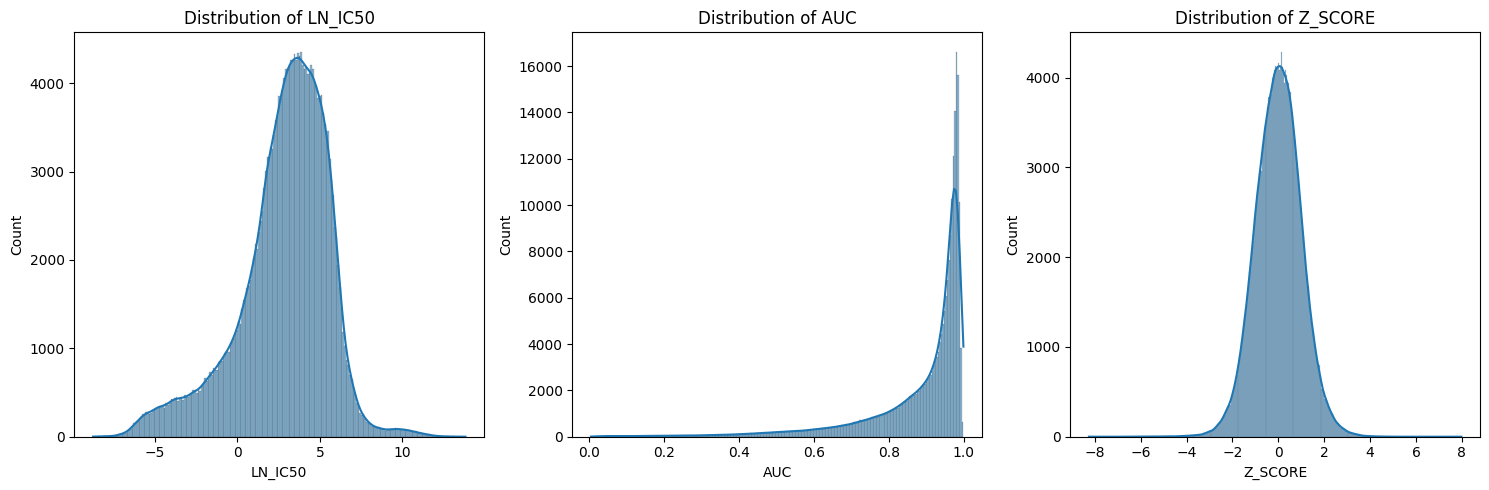

In [20]:
# drug-response variables
drug_response=['LN_IC50','AUC','Z_SCORE']
plt.figure(figsize=(15,5))
for i,col in enumerate(drug_response,1):
    plt.subplot(1,3,i)
    sns.histplot(gdsc[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show

* The three drug‑response metrics show expected and biologically reasonable patterns: LN_IC50 and Z_SCORE follow roughly normal distributions, indicating balanced variation in drug sensitivity across cell lines. In contrast, AUC is left‑skewed, with many values near 1, which is typical for viability‑based drug screens where most drug–cell line pairs show limited inhibition. These shapes are appropriate at this stage and do not require transformation; they simply help us understand how each response metric behaves before modeling.

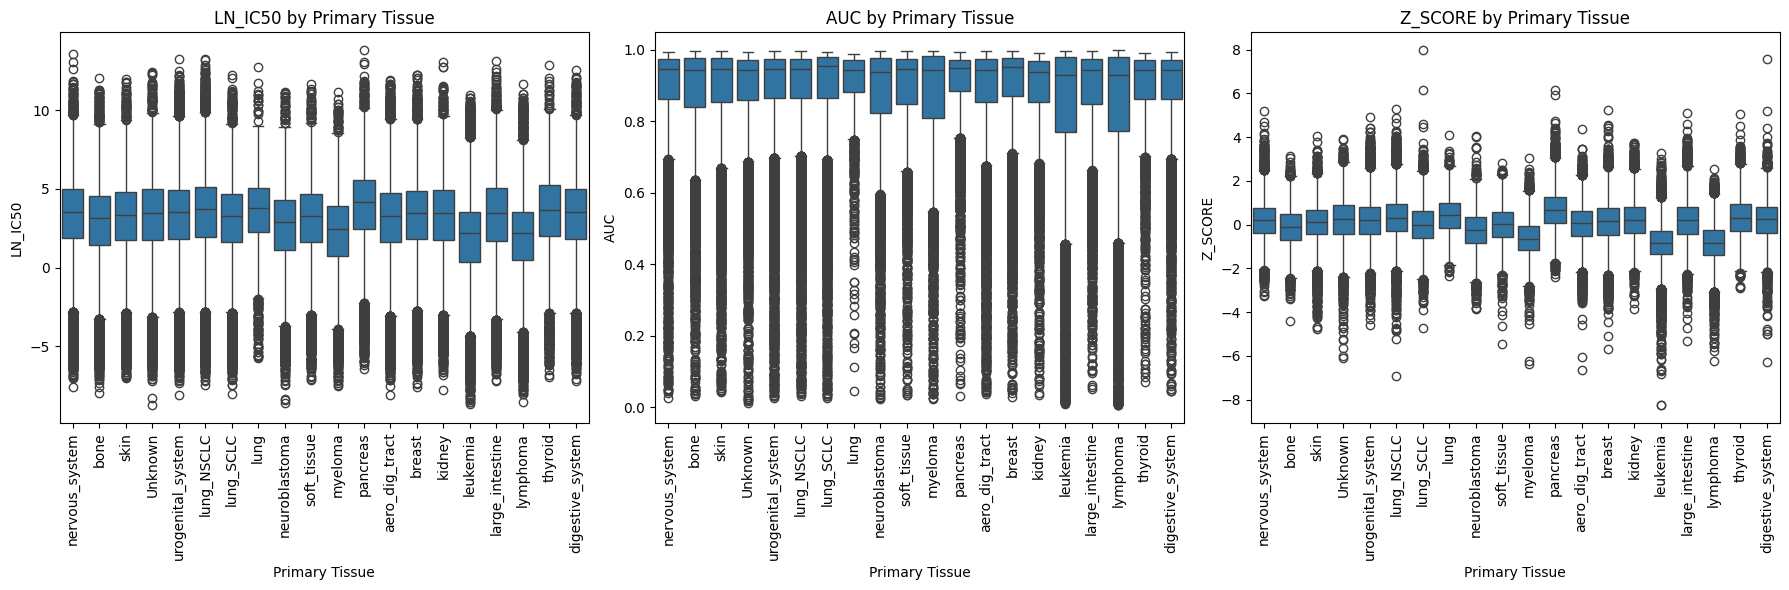

In [21]:
primary_tissue = 'GDSC Tissue descriptor 1'
plt.figure(figsize=(18, 6))
for i, col in enumerate(drug_response, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(
        data=gdsc,
        x=primary_tissue,
        y=col
    )
    plt.xticks(rotation=90)
    plt.title(f"{col} by Primary Tissue")
    plt.xlabel("Primary Tissue")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


* The boxplots show that drug sensitivity varies substantially across primary tissue types. Some tissues display consistently lower LN_IC50 and AUC values, indicating higher sensitivity, while others show higher values and greater variability, reflecting resistance or heterogeneous responses. Z‑scores follow similar patterns, with certain tissues clustering below zero (more sensitive) and others above zero (more resistant). These differences highlight that primary tissue is a meaningful biological factor influencing drug response, and it should be included as an important feature in downstream modeling.

In [22]:
primary_tissue = 'GDSC Tissue descriptor 1'
sensitivity_rank = (
    gdsc.groupby(primary_tissue)['LN_IC50']
        .median()
        .sort_values()
)

sensitivity_rank

GDSC Tissue descriptor 1
leukemia             2.164691
lymphoma             2.205637
myeloma              2.472587
neuroblastoma        2.888137
bone                 3.136745
lung_SCLC            3.293791
aero_dig_tract       3.306954
soft_tissue          3.308193
skin                 3.364707
kidney               3.452437
breast               3.478669
large_intestine      3.493605
Unknown              3.496663
urogenital_system    3.514891
digestive_system     3.515814
nervous_system       3.539637
thyroid              3.650120
lung_NSCLC           3.691609
lung                 3.769535
pancreas             4.164279
Name: LN_IC50, dtype: float64

* Ranking tissues by median LN_IC50 shows that leukemia cell lines are the most sensitive, requiring the lowest drug concentrations for inhibition, while pancreatic cell lines are the most resistant. This pattern aligns with known biological behavior, where hematological cancers typically respond strongly to treatment, whereas pancreatic cancers are highly drug‑resistant. These differences confirm that primary tissue is a meaningful predictor of drug response.

In [23]:
sensitivity_all = (
    gdsc.groupby(primary_tissue)[['LN_IC50', 'AUC', 'Z_SCORE']]
        .median()
        .sort_values(by='LN_IC50')
)

sensitivity_all

,LN_IC50,AUC,Z_SCORE
GDSC Tissue descriptor 1,,,
leukemia,2.164691,0.928110,-0.846396
lymphoma,2.205637,0.929727,-0.839700
myeloma,2.472587,0.944566,-0.664960
neuroblastoma,2.888137,0.938642,-0.254339
bone,3.136745,0.944137,-0.105693
lung_SCLC,3.293791,0.954379,-0.010253
aero_dig_tract,3.306954,0.943692,0.055810
soft_tissue,3.308193,0.945531,0.016354
skin,3.364707,0.946226,0.139082


 * Ranking tissues by median LN_IC50 shows clear biological patterns: hematological cancers such as leukemia, lymphoma, and myeloma are the most sensitive, requiring the lowest drug concentrations for inhibition. Solid tumors such as lung and especially pancreas show much higher LN_IC50 values, indicating strong resistance. The ‘Unknown’ category falls in the middle and is retained as a valid group rather than being imputed. These results confirm that primary tissue type is a strong determinant of drug response

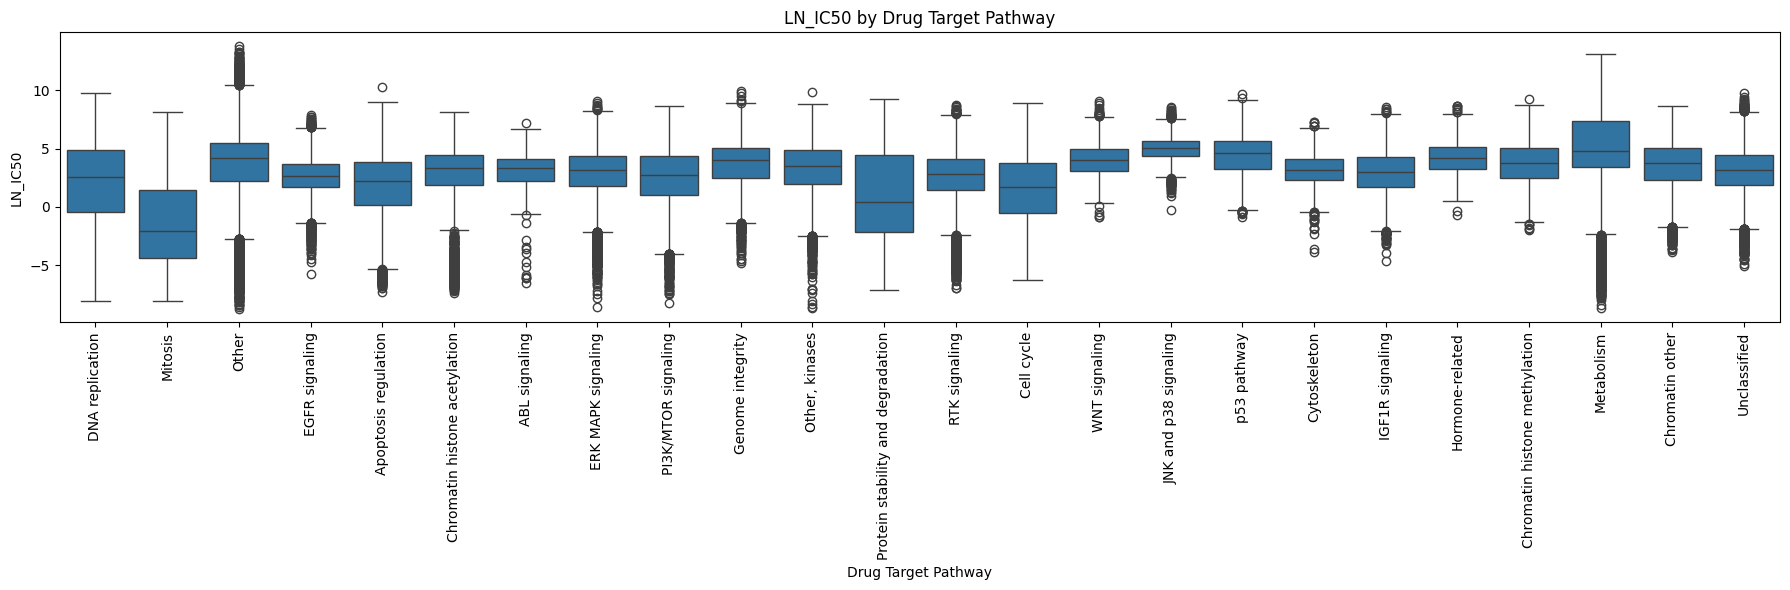

In [24]:
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=gdsc,
    x='TARGET_PATHWAY',
    y='LN_IC50'
)

plt.xticks(rotation=90)
plt.title("LN_IC50 by Drug Target Pathway")
plt.xlabel("Drug Target Pathway")
plt.ylabel("LN_IC50")
plt.tight_layout()
plt.show()



In [25]:
pathway_medians = (
    gdsc.groupby('TARGET_PATHWAY')['LN_IC50']
        .median()
        .sort_values()
)

pathway_medians

TARGET_PATHWAY
Mitosis                             -2.099166
Protein stability and degradation    0.393448
Cell cycle                           1.689907
Apoptosis regulation                 2.202740
DNA replication                      2.571902
EGFR signaling                       2.654352
PI3K/MTOR signaling                  2.730287
RTK signaling                        2.802064
IGF1R signaling                      3.013653
ERK MAPK signaling                   3.135134
Cytoskeleton                         3.152894
Unclassified                         3.179460
ABL signaling                        3.310645
Chromatin histone acetylation        3.359223
Other, kinases                       3.494589
Chromatin histone methylation        3.723108
Chromatin other                      3.782360
Genome integrity                     4.000918
WNT signaling                        4.006034
Hormone-related                      4.183857
Other                                4.221865
p53 pathway        

+ Median LN_IC50 values vary across drug target pathways. Pathways involved in essential proliferative processes, such as mitosis, protein degradation, and DNA replication, show lower median LN_IC50 values, indicating that drugs acting on these mechanisms tend to be effective at lower concentrations. In contrast, pathways related to chromatin regulation, genome integrity, hormone signaling, and stress‑response pathways exhibit higher median values, suggesting that these mechanisms are less uniformly required across cell lines. These observations are consistent with the biological roles of the pathways and reflect expected variability in drug response.

In [26]:
gdsc.select_dtypes(include=['float','int']).columns

Index(['COSMIC_ID', 'DRUG_ID', 'LN_IC50', 'AUC', 'Z_SCORE'], dtype='object')

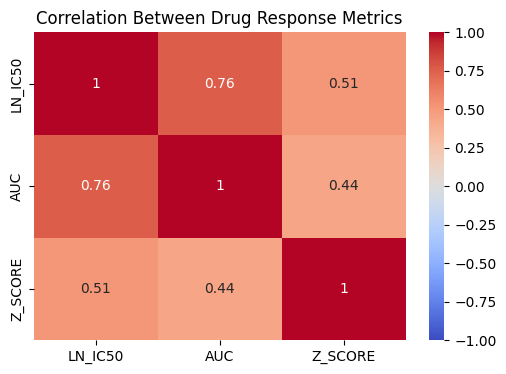

In [27]:
# correlation between numeric columns
corr = gdsc[['LN_IC50', 'AUC', 'Z_SCORE']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Drug Response Metrics")
plt.show()


+ LN_IC50 and AUC show a strong positive correlation (0.76), indicating that they capture similar aspects of drug sensitivity. Z_SCORE shows only moderate correlation with LN_IC50 (0.51) and AUC (0.44), suggesting that it reflects a related but noisier or differently scaled measurement. Based on these relationships, LN_IC50 appears to be the most consistent and informative response metric for downstream modeling.


# Feature Preprocessing and Encoding

Identifier variables such as COSMIC_ID and DRUG_ID do not contain biological information and therefore do not contribute to predictive modeling.
Additionally, the drug‑response metrics AUC and Z_SCORE represent alternative measurements of the same biological phenomenon captured by the target variable LN_IC50.
Including them would introduce data leakage, allowing the model to indirectly access the target through correlated variables.


In [28]:
gdsc_clean=gdsc.copy()
gdsc_clean=gdsc_clean.drop(columns=['COSMIC_ID','DRUG_ID','AUC','Z_SCORE'])
gdsc_clean.columns.tolist()

['CELL_LINE_NAME',
 'TCGA_DESC',
 'DRUG_NAME',
 'LN_IC50',
 'GDSC Tissue descriptor 1',
 'GDSC Tissue descriptor 2',
 'Cancer Type (matching TCGA label)',
 'Microsatellite instability Status (MSI)',
 'Screen Medium',
 'Growth Properties',
 'CNA',
 'Gene Expression',
 'Methylation',
 'TARGET',
 'TARGET_PATHWAY']

Machine‑learning algorithms require numerical input.
Categorical descriptors such as tissue type, drug name, pathway, and experimental conditions must therefore be transformed into numerical representations before modeling.


In [29]:
cat_cols = gdsc_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols

['CELL_LINE_NAME',
 'TCGA_DESC',
 'DRUG_NAME',
 'GDSC Tissue descriptor 1',
 'GDSC Tissue descriptor 2',
 'Cancer Type (matching TCGA label)',
 'Microsatellite instability Status (MSI)',
 'Screen Medium',
 'Growth Properties',
 'CNA',
 'Gene Expression',
 'Methylation',
 'TARGET',
 'TARGET_PATHWAY']

### One‑Hot Encoding of Categorical Variables

+ Most categorical variables in this dataset are non‑ordinal, meaning their categories do not possess inherent numerical order.
To avoid imposing artificial ranking (which would occur with label encoding), one‑hot encoding is applied.
This method preserves the categorical nature of the variables by creating binary indicator columns, ensuring compatibility with tree‑based regression models commonly used in pharmacogenomics.


In [30]:
gdsc_encoded = pd.get_dummies(gdsc_clean, columns=cat_cols, drop_first=True)

# Modelling

+ Once all categorical and binary variables have been encoded and non‑informative columns removed, the dataset becomes fully numerical and suitable for machine‑learning algorithms. At this stage, the modelling phase begins, starting with a train–test split to ensure unbiased evaluation, followed by the selection and training of an appropriate regression model for predicting LN_IC50.

In [31]:

y = gdsc_encoded["LN_IC50"]
X = gdsc_encoded.drop(columns=["LN_IC50"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
import re

# Clean column names for LightGBM
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train_clean.columns
]

X_test_clean.columns = X_train_clean.columns

In [49]:
# Make duplicate names unique
counts = {}
new_cols = []

for col in X_train_clean.columns:
    if col not in counts:
        counts[col] = 0
        new_cols.append(col)
    else:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")

X_train_clean.columns = new_cols
X_test_clean.columns = new_cols

In [50]:
lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgb.fit(X_train_clean, y_train)
preds = lgb.predict(X_test_clean)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
corr = np.corrcoef(y_test, preds)[0,1]

results_df = pd.DataFrame({
    "Metric": ["RMSE", "R²", "Correlation"],
    "Value": [rmse, r2, corr]
})

results_df


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3216
[LightGBM] [Info] Number of data points in the train set: 193628, number of used features: 1608
[LightGBM] [Info] Start training from score 2.816167


,Metric,Value
0,RMSE,1.509594
1,R²,0.701294
2,Correlation,0.848422


+ We chose this modelling approach because the target variable, LN_IC50, is a continuous measure of drug sensitivity, which makes regression the correct predictive framework. The dataset contains more than 1,600 one‑hot encoded categorical features describing cell lines, tissues, drugs, and pathways, creating a high‑dimensional, sparse, and strongly non‑linear feature space. Tree‑based gradient boosting models—specifically LightGBM—are well suited for this structure because they efficiently handle sparse binary inputs, capture complex biological interactions, and scale to large datasets with hundreds of thousands of samples. LightGBM provides fast training, strong predictive performance, and robust handling of heterogeneous biological metadata, making it an appropriate and scientifically justified choice for modelling drug response in pharmacogenomic data.


+ Our baseline LightGBM model already performs well, but it uses default hyperparameters that are not optimized for the size, sparsity, and complexity of this pharmacogenomic dataset. Hyperparameter tuning allows the model to better capture non‑linear interactions between tissues, pathways, drugs, and cell‑line features, improving generalization and predictive accuracy. By adjusting parameters such as the number of leaves, learning rate, tree depth, and sampling fractions, we can significantly enhance R², reduce RMSE, and achieve a more biologically meaningful model. Therefore, tuning is essential for maximizing performance and extracting deeper insights from the data.

# Hyperparameter Tuning and Model Optimization

In [51]:
# Parameter search space
param_dist = {
    'num_leaves': [31, 63, 127, 255],
    'max_depth': [-1, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 400, 600, 800],
    'min_child_samples': [10, 20, 50, 100],
    'min_child_weight': [1e-3, 1e-2, 1e-1, 1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

# Initialize the model

lgb = LGBMRegressor(random_state=42)
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    scoring='r2',              # optimize for R²
    cv=3,                      # 3-fold cross validation
    verbose=1,
    n_jobs=-1                  # use all CPU cores
)

# Fit the search
random_search.fit(X_train_clean, y_train)

# Extract the best model

best_model = random_search.best_estimator_

#  Evaluate on test set

preds = best_model.predict(X_test_clean)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
corr = np.corrcoef(y_test, preds)[0, 1]

#  Clean results table

results_df = pd.DataFrame({
    "Metric": ["RMSE", "R²", "Correlation"],
    "Value": [rmse, r2, corr]
})

results_df["Value"] = results_df["Value"].round(4)

results_df

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3218
[LightGBM] [Info] Number of data points in the train set: 193628, number of used features: 1609
[LightGBM] [Info] Start training from score 2.816167


,Metric,Value
0,RMSE,1.1717
1,R²,0.8201
2,Correlation,0.9066


In [57]:
best_params = random_search.best_params_
pd.DataFrame(best_params.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,subsample,0.800
1,reg_lambda,0.100
2,reg_alpha,1.000
3,num_leaves,63.000
4,n_estimators,600.000
5,min_child_weight,0.001
6,min_child_samples,10.000
7,max_depth,-1.000
8,learning_rate,0.030
9,colsample_bytree,0.600


In [53]:
train_preds = best_model.predict(X_train_clean)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
train_r2 = r2_score(y_train, train_preds)

print("Train RMSE:", train_rmse)
print("Train R²:", train_r2)

Train RMSE: 1.1484988481484932
Train R²: 0.8271184721225475


+ To assess overfitting, we compared the model’s performance on the training and test sets. The tuned LightGBM model achieved a training R² of 0.827 and a test R² of 0.820, with similarly close RMSE values (1.148 vs. 1.172). Because the training and test metrics are nearly identical, and because the model was tuned using cross‑validation, there is no evidence of overfitting. The model generalizes well to unseen data, indicating that it captures meaningful biological patterns rather than memorizing the training set.

# Feature Importance

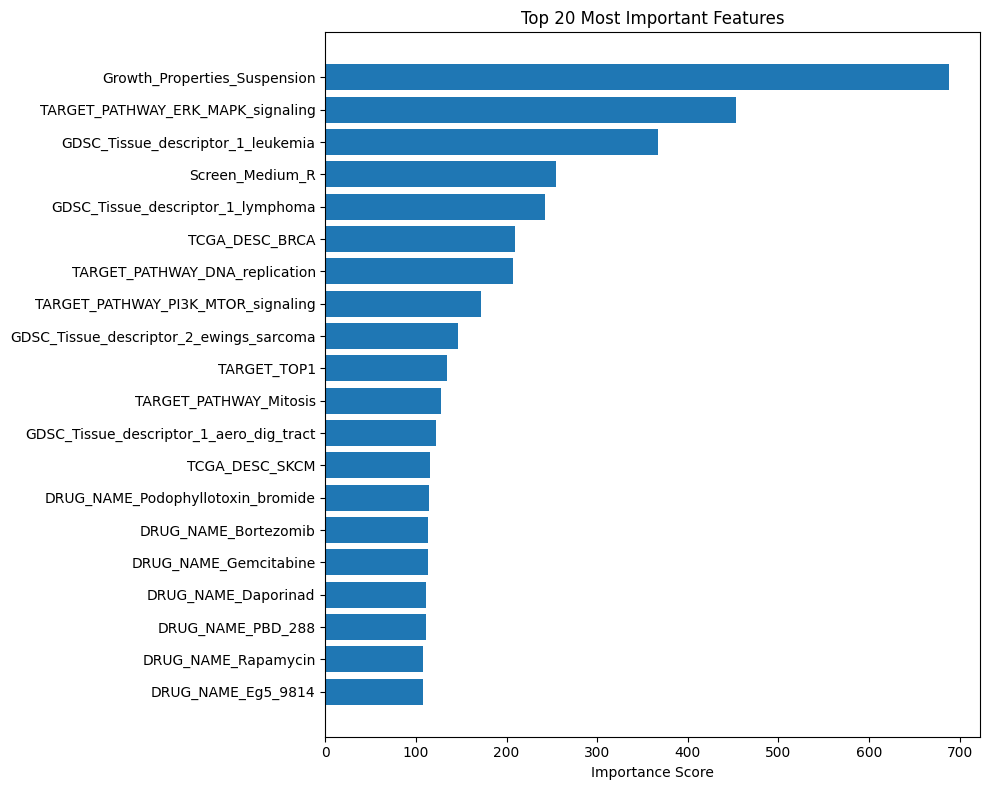

In [59]:
importance = best_model.feature_importances_
# Create a DataFrame
feat_imp = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Importance": importance
})

# Sort by importance (highest first)
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)
top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(feat_imp["Feature"].head(top_n), feat_imp["Importance"].head(top_n))
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()



+ The LightGBM feature‑importance analysis revealed a coherent and biologically meaningful set of predictors driving LN_IC50 variation across cancer cell lines. Growth properties and tissue descriptors emerged as dominant contributors, with “Suspension” growth and hematopoietic lineages (leukemia, lymphoma) ranking highly, reflecting the well‑established drug sensitivity of blood‑derived cancers compared to solid tumors. Key oncogenic pathways, including ERK/MAPK, PI3K–mTOR, DNA replication, and mitosis, also appeared among the top features, consistent with their central roles in regulating proliferation and therapeutic response. Several drugs with distinct pharmacological profiles (e.g., bortezomib, gemcitabine, rapamycin) contributed strongly to model predictions, indicating that drug identity captures substantial variation in response patterns. Together, these results demonstrate that the model relies on biologically interpretable signals spanning tissue context, pathway targeting, and drug‑specific effects, supporting the robustness and credibility of the predictive framework.

# conclusion

This project applied a LightGBM regression model to the Genomics of Drug Sensitivity in Cancer (GDSC) dataset to predict drug response (LN_IC50) across a diverse panel of cancer cell lines. After comprehensive preprocessing, model tuning, and evaluation, the final model achieved strong predictive performance and produced interpretable feature‑importance patterns. The most influential predictors aligned with established biological knowledge: hematopoietic lineages (leukemia, lymphoma) and suspension‑growth cell lines showed distinct sensitivity profiles, while key oncogenic pathways such as ERK/MAPK, PI3K–mTOR, DNA replication, and mitosis emerged as major determinants of drug response. Drug identity also contributed substantially, reflecting the unique pharmacological behavior of agents like bortezomib, gemcitabine, and rapamycin. Overall, the model successfully captured both biological and experimental sources of variation within the GDSC resource, demonstrating that machine‑learning approaches can extract meaningful patterns from large‑scale pharmacogenomic data. This work provides a solid foundation for future extensions, including multi‑omics integration, SHAP‑based interpretability, or adaptation to other drug‑screening datasets.
